# Homework 1 — EDA: ASHRAE Great Energy Predictor III

Predict the hourly energy use (`meter_reading`) of ~1,450 buildings at 16 sites, for 4 meter types.
Metric: **RMSLE**. Follows the [Stage 1 EDA guide](../../../Development%20Guide/EDA_guide.md).

| File | One row per | Key |
|---|---|---|
| `building_metadata.csv` | building | `building_id` → `site_id` |
| `train.csv` / `test.csv` | building × meter × hour | `building_id`, `meter`, `timestamp` |
| `weather_[train/test].csv` | site × hour | `site_id`, `timestamp` |

## Agenda

1. [Setup & loading](#setup)
2. [Data overview](#overview)
3. [Data quality](#quality)
4. [Building metadata](#buildings)
5. [Target](#target)
6. [Temporal patterns](#temporal)
7. [Features vs target](#relationships)
8. [Metric: RMSLE](#metric)
9. [Anomalies](#broken)
10. [Summary](#summary)

## Data description

- `meter_reading` — the target, hourly energy use. Real meter data: noisy, with gaps and long zero runs.
- Building metadata: `site_id`, `primary_use` (16 categories), `square_feet`, `year_built`, `floor_count`.
- Weather, from the station nearest each site: air and dew temperature (°C), cloud coverage (oktas),
  precipitation (mm), sea-level pressure (hPa), wind direction (degrees) and wind speed (m/s).
- `test.csv` has the same keys plus `row_id`, and no target.

**Meter types** are different physical quantities, so readings are never pooled or averaged across them:

| `meter` | Type | Unit | Note |
|---|---|---|---|
| 0 | electricity | kWh | Site 0 is in kBTU (× 0.2931 for kWh). Zero readings are broken meters (§9). |
| 1 | chilled water | kWh equivalent | Cooling; can be zero out of season. |
| 2 | steam | kWh equivalent | Heating; can be zero out of season. |
| 3 | hot water | kWh equivalent | Heating; can be zero out of season. |

<a id='setup'></a>

# 1. Setup & loading


In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import METERS, UTC_OFFSET
from ashrae.data import anomaly_flags, read_building, read_processed, read_readings, read_weather
from ashrae.metrics import rmsle as rmsle_log

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
building, train, weather = read_building(), read_readings("train.csv"), read_weather("weather_train.csv")

for name, df in [("building", building), ("train", train), ("weather", weather)]:
    print(
        f"{name:9s} shape={df.shape}  memory={df.memory_usage(deep=True).sum() / 2**20:,.1f} MB"
    )

building  shape=(1449, 6)  memory=0.0 MB
train     shape=(20216100, 4)  memory=289.2 MB
weather   shape=(139773, 9)  memory=4.9 MB


<a id='overview'></a>

# 2. Data overview


In [3]:
display(building.head())
display(train.head())
display(weather.head())

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,"2,008.000",NaN
1,0,1,Education,2720,"2,004.000",NaN
2,0,2,Education,5376,"1,991.000",NaN
3,0,3,Education,23685,"2,002.000",NaN
4,0,4,Education,116607,"1,975.000",NaN


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.000
1,1,0,2016-01-01,0.000
2,2,0,2016-01-01,0.000
3,3,0,2016-01-01,0.000
4,4,0,2016-01-01,0.000


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.000,6.000,20.000,NaN,"1,019.700",0.000,0.000
1,0,2016-01-01 01:00:00,24.400,NaN,21.100,-1.000,"1,020.200",70.000,1.500
2,0,2016-01-01 02:00:00,22.800,2.000,21.100,0.000,"1,020.200",0.000,0.000
3,0,2016-01-01 03:00:00,21.100,2.000,20.600,0.000,"1,020.100",0.000,0.000
4,0,2016-01-01 04:00:00,20.000,2.000,20.000,-1.000,"1,020.000",250.000,2.600


In [4]:
print("train timestamps :", train.timestamp.min(), "->", train.timestamp.max())
print("weather timestamps:", weather.timestamp.min(), "->", weather.timestamp.max())
print()
print(
    "buildings in metadata:",
    building.building_id.nunique(),
    "| in train:",
    train.building_id.nunique(),
)
print(
    "sites in metadata    :",
    building.site_id.nunique(),
    "| in weather:",
    weather.site_id.nunique(),
)
print(
    "building_id range    :",
    building.building_id.min(),
    "-",
    building.building_id.max(),
)
print()
print(
    "Meter series (building x meter) in train:",
    train.groupby(["building_id", "meter"]).ngroups,
)
print(train.meter.map(METERS).value_counts().rename("rows per meter"))

train timestamps : 2016-01-01 00:00:00 -> 2016-12-31 23:00:00
weather timestamps: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00

buildings in metadata: 1449 | in train: 1449
sites in metadata    : 16 | in weather: 16
building_id range    : 0 - 1448



Meter series (building x meter) in train: 2380


meter
electricity     12060910
chilledwater     4182440
steam            2708713
hotwater         1264037
Name: rows per meter, dtype: int64


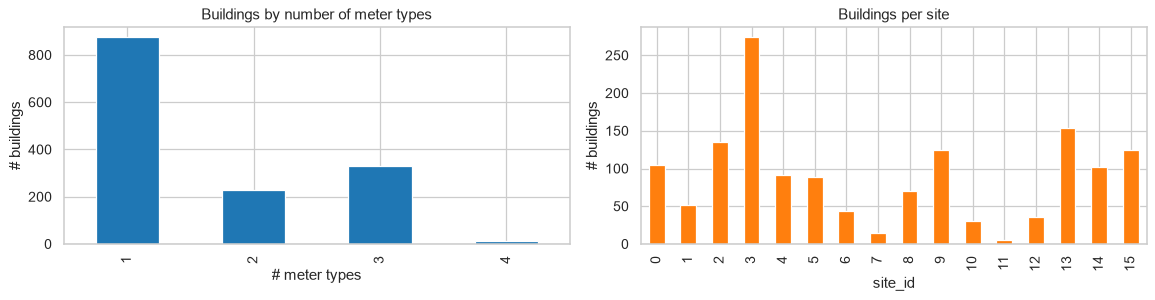

In [5]:
meters_per_building = (
    train.groupby("building_id").meter.nunique().value_counts().sort_index()
)
buildings_per_site = building.groupby("site_id").building_id.count()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
meters_per_building.plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(
    title="Buildings by number of meter types",
    xlabel="# meter types",
    ylabel="# buildings",
)
buildings_per_site.plot.bar(ax=axes[1], color="tab:orange")
axes[1].set(title="Buildings per site", xlabel="site_id", ylabel="# buildings")
plt.tight_layout()

<a id='quality'></a>

# 3. Data quality

## 3.1 Missing values


In [6]:
def missing_report(df):
    miss = df.isna().mean().mul(100).rename("% missing")
    return miss[miss > 0].sort_values(ascending=False).to_frame()


print("building_metadata")
display(missing_report(building))
print("train")
display(missing_report(train))
print("weather_train")
display(missing_report(weather))

building_metadata


,% missing
floor_count,75.500
year_built,53.416


train


,% missing


weather_train


,% missing
cloud_coverage,49.490
precip_depth_1_hr,35.979
sea_level_pressure,7.597
wind_direction,4.484
wind_speed,0.217
dew_temperature,0.081
air_temperature,0.039


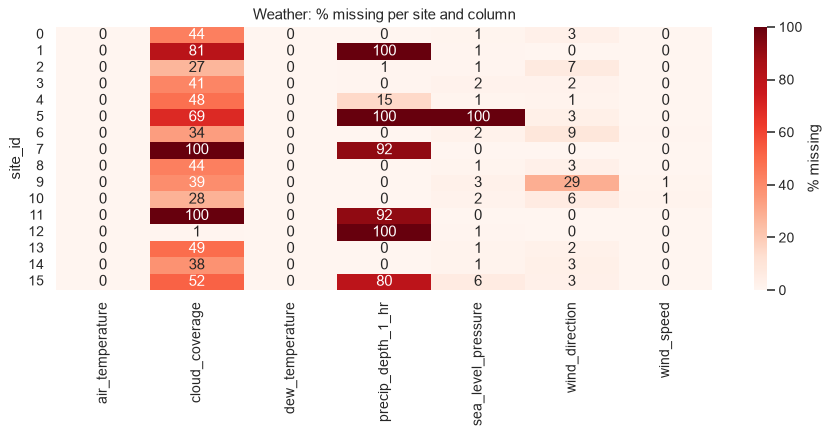

In [7]:
weather_missing_by_site = (
    weather.drop(columns="timestamp")
    .groupby("site_id")
    .agg(lambda s: s.isna().mean() * 100)
)
plt.figure(figsize=(10, 5))
sns.heatmap(
    weather_missing_by_site,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar_kws={"label": "% missing"},
)
plt.yticks(rotation=0)
plt.title("Weather: % missing per site and column")
plt.tight_layout()

## 3.2 Duplicates and missing hours


In [8]:
print("duplicate building rows      :", building.building_id.duplicated().sum())
print(
    "duplicate train keys         :",
    train.duplicated(["building_id", "meter", "timestamp"]).sum(),
)
print(
    "duplicate weather keys       :", weather.duplicated(["site_id", "timestamp"]).sum()
)

HOURS_2016 = 366 * 24  # leap year
weather_hours = (
    weather.groupby("site_id").timestamp.nunique().rename("hours present").to_frame()
)
weather_hours["hours missing"] = HOURS_2016 - weather_hours["hours present"]
display(weather_hours.T)

duplicate building rows      : 0


duplicate train keys         : 0
duplicate weather keys       : 0


site_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
hours present,8784,8763,8783,8780,8783,8755,8782,8614,8784,8780,8782,8614,8755,8783,8777,8454
hours missing,0,21,1,4,1,29,2,170,0,4,2,170,29,1,7,330


<a id='buildings'></a>

# 4. Building metadata


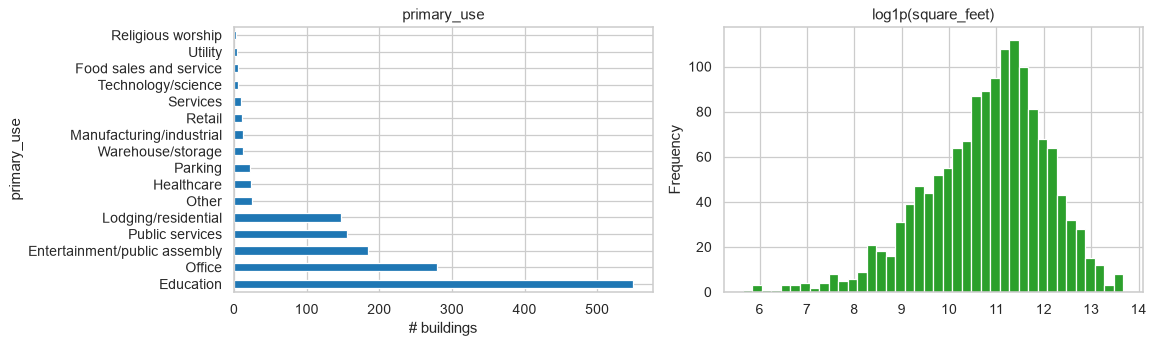

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
building.primary_use.value_counts().plot.barh(ax=axes[0], color="tab:blue")
axes[0].set(title="primary_use", xlabel="# buildings")
np.log1p(building.square_feet).plot.hist(bins=40, ax=axes[1], color="tab:green")
axes[1].set(title="log1p(square_feet)")
plt.tight_layout()

In [10]:
# Is missingness site-dependent? (informative missingness / different data sources)
meta_missing = (
    building.groupby("site_id")[["year_built", "floor_count"]]
    .agg(lambda s: s.isna().mean() * 100)
    .round(0)
)
display(meta_missing.T)

site_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
year_built,0.000,22.000,30.000,52.000,2.000,1.000,100.000,7.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,9.000
floor_count,100.000,0.000,100.000,100.000,0.000,0.000,100.000,0.000,0.000,100.000,0.000,100.000,75.000,100.000,100.000,100.000


<a id='target'></a>

# 5. Target


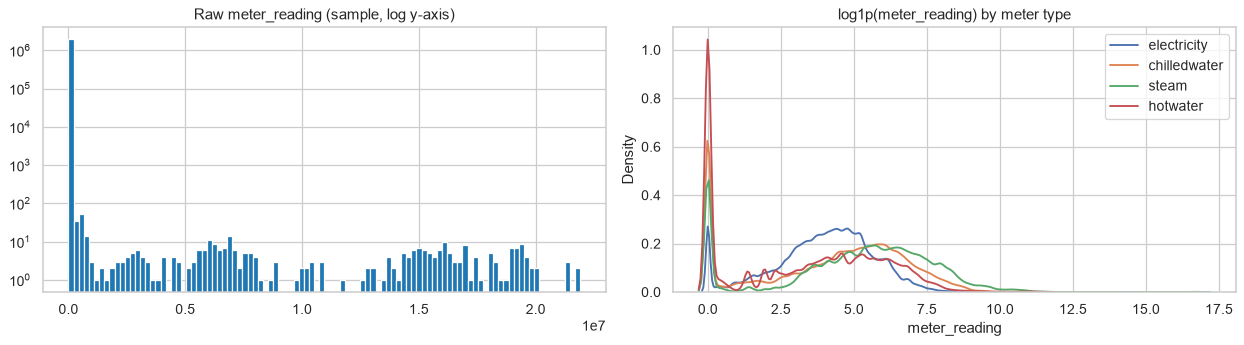

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(
    train.meter_reading.sample(2_000_000, random_state=0),
    bins=100,
    log=True,
    color="tab:blue",
)
axes[0].set(title="Raw meter_reading (sample, log y-axis)")
for m, name in METERS.items():
    sns.kdeplot(
        np.log1p(
            train.loc[train.meter == m, "meter_reading"].sample(300_000, random_state=0)
        ),
        ax=axes[1],
        label=name,
        bw_adjust=0.5,
    )
axes[1].set(title="log1p(meter_reading) by meter type")
axes[1].legend()
plt.tight_layout()

In [12]:
zero_share = (
    (train.meter_reading == 0).groupby(train.meter.map(METERS)).mean().mul(100)
)
print("% zero readings per meter type:")
print(zero_share.round(1).to_string())

% zero readings per meter type:
meter
chilledwater   15.700
electricity     4.400
hotwater       26.900
steam          12.800


In [13]:
series_total = train.groupby(["building_id", "meter"]).meter_reading.sum()
building_id, meter = series_total.idxmax()
print(
    f"Largest series: building {building_id}, {METERS[meter]} — "
    f"{series_total.max() / series_total.sum():.1%} of all energy in train"
)

Largest series: building 1099, steam — 78.3% of all energy in train


<a id='temporal'></a>

# 6. Temporal patterns


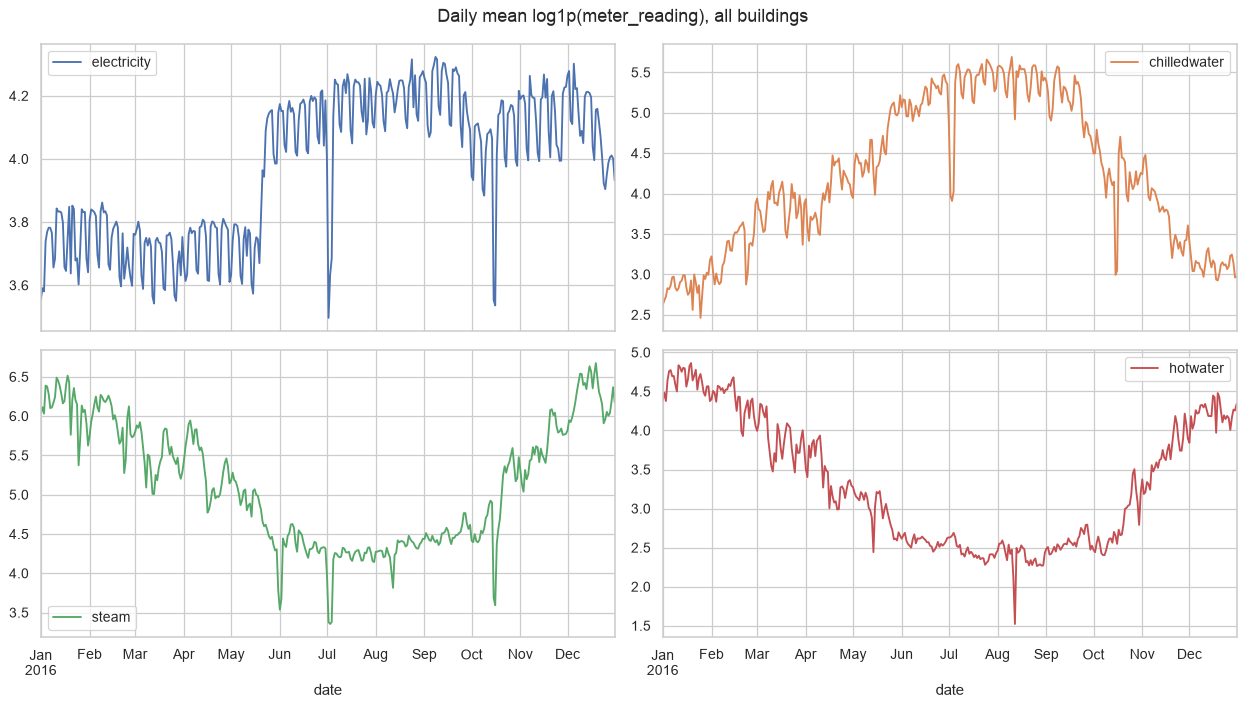

In [14]:
daily = (
    train.assign(
        date=train.timestamp.dt.floor("D"), log_reading=np.log1p(train.meter_reading)
    )
    .groupby(["meter", "date"])
    .log_reading.mean()
    .unstack(0)
    .rename(columns=METERS)
)
daily.plot(
    subplots=True,
    figsize=(14, 8),
    layout=(2, 2),
    title="Daily mean log1p(meter_reading), all buildings",
)
plt.tight_layout()

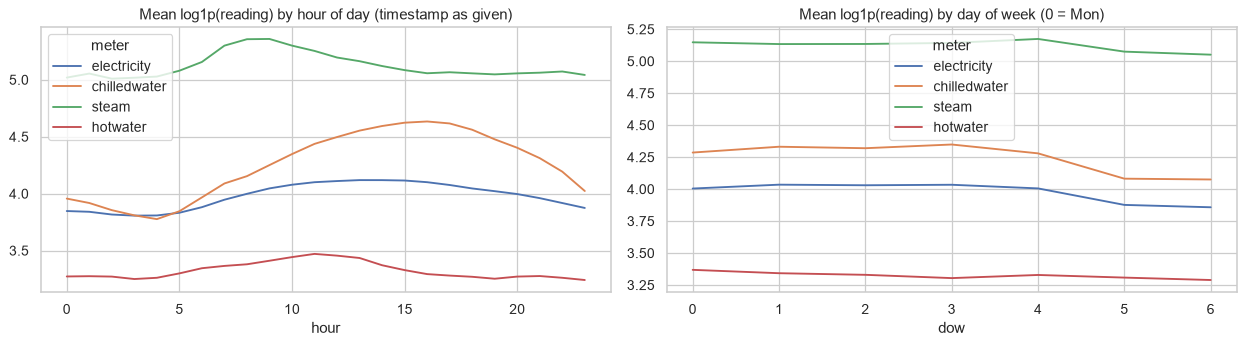

In [15]:
hour_prof = (
    train.assign(
        hour=train.timestamp.dt.hour, log_reading=np.log1p(train.meter_reading)
    )
    .groupby(["meter", "hour"])
    .log_reading.mean()
    .unstack(0)
    .rename(columns=METERS)
)
dow_prof = (
    train.assign(
        dow=train.timestamp.dt.dayofweek, log_reading=np.log1p(train.meter_reading)
    )
    .groupby(["meter", "dow"])
    .log_reading.mean()
    .unstack(0)
    .rename(columns=METERS)
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hour_prof.plot(
    ax=axes[0], title="Mean log1p(reading) by hour of day (timestamp as given)"
)
dow_prof.plot(ax=axes[1], title="Mean log1p(reading) by day of week (0 = Mon)")
plt.tight_layout()

## 6.1 Time zones: weather is in UTC

Suspected in a [Kaggle discussion](https://www.kaggle.com/c/ashrae-energy-prediction/discussion/115698): weather
timestamps are UTC, meter timestamps local, so the two are misaligned by the site's UTC offset.

Check: in local time, temperature should peak around 14:00–15:00, and electricity during the working day.

In [16]:
# Site locations from the Kaggle discussion; their UTC offsets are UTC_OFFSET in ashrae/config.py
SITE_LOCATION = {
    0: "Orlando, FL", 1: "UK (likely Southampton)", 2: "Tempe, AZ", 3: "Washington, DC",
    4: "US Pacific (likely Berkeley)", 5: "UK", 6: "US Eastern", 7: "Montreal/Ottawa",
    8: "Orlando, FL", 9: "Austin, TX", 10: "US Mountain", 11: "Montreal/Ottawa",
    12: "Ireland", 13: "Minneapolis-St Paul, MN", 14: "Charlottesville, VA", 15: "US Eastern",
}

elec = train[(train.meter == 0) & (train.meter_reading > 0)].merge(
    building[["building_id", "site_id"]], on="building_id"
)
elec["relative"] = elec.meter_reading / elec.groupby("building_id").meter_reading.transform("mean")

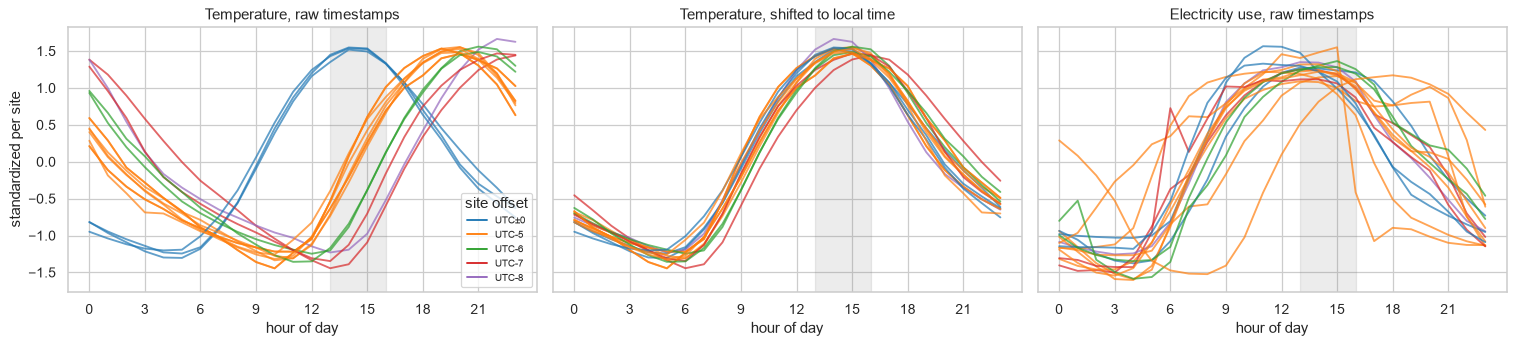

In [17]:
def hourly_profile(df, value, offsets=None):
    hour = df.timestamp.dt.hour
    if offsets is not None:
        hour = (hour + df.site_id.map(offsets)) % 24
    profile = df.assign(hour=hour).groupby(["site_id", "hour"])[value].mean().unstack(0)
    return (profile - profile.mean()) / profile.std()  # standardized per site, so sites share one scale


panels = [
    ("Temperature, raw timestamps", hourly_profile(weather, "air_temperature")),
    ("Temperature, shifted to local time", hourly_profile(weather, "air_temperature", UTC_OFFSET)),
    ("Electricity use, raw timestamps", hourly_profile(elec, "relative")),
]
colors = {0: "tab:blue", -5: "tab:orange", -6: "tab:green", -7: "tab:red", -8: "tab:purple"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, (title, profile) in zip(axes, panels):
    for site in profile.columns:
        ax.plot(profile.index, profile[site], color=colors[UTC_OFFSET[site]], alpha=0.7)
    ax.axvspan(13, 16, color="gray", alpha=0.15)
    ax.set(title=title, xlabel="hour of day", xticks=range(0, 24, 3))
axes[0].set_ylabel("standardized per site")
axes[0].legend(
    handles=[plt.Line2D([], [], color=c, label=f"UTC{o:+d}" if o else "UTC±0") for o, c in colors.items()],
    title="site offset",
    fontsize=8,
)
plt.tight_layout()

In [18]:
# Hour shift that best lines up each site's electricity profile with the average of the other sites
def best_alignment(profile, site):
    others = profile.drop(columns=site).mean(axis=1)
    corr = pd.Series(
        {k: np.corrcoef(np.roll(profile[site].to_numpy(), -k), others)[0, 1] for k in range(-12, 12)}
    )
    return {"shift": corr.idxmax(), "corr_best": corr.max(), "corr_none": corr[0]}


alignment = pd.DataFrame({s: best_alignment(panels[2][1], s) for s in UTC_OFFSET}).T
site14 = alignment.loc[14]
print(f"site 14: best shift {site14['shift']:+.0f} h, correlation {site14['corr_none']:.2f} -> {site14['corr_best']:.2f}")
print(f"other sites: best shift within ±{alignment.drop(14)['shift'].abs().max():.0f} h")
del elec

site 14: best shift +5 h, correlation 0.24 -> 0.99
other sites: best shift within ±3 h


- **Weather is in UTC.** Raw (left), temperature peaks at 14:00 at European sites and 19:00–23:00 at North American
  ones. Shifted by each site's offset (middle), every site peaks at 14:00–16:00.
- **Meters are in local time, except site 14.** Unshifted electricity (right) peaks in the working day at 15 of 16
  sites. Site 14 needs +5 h, exactly its offset, so its meters are UTC too.
- **Fix:** shift weather by the site's offset before merging, except at site 14. LightGBM baseline (§9, fold
  average): 1.290 → 1.286 on all rows, 1.147 → 1.140 on clean rows. Small, but no fold gets worse.

<a id='relationships'></a>

# 7. Features vs target


In [19]:
# Join on a sample to keep memory reasonable
sample = (
    train.sample(3_000_000, random_state=0)
    .merge(building, on="building_id", how="left")
    .merge(weather, on=["site_id", "timestamp"], how="left")
)
sample["log_reading"] = np.log1p(sample.meter_reading)
sample["meter_name"] = sample.meter.map(METERS)
print("rows without matching weather:", f"{sample.air_temperature.isna().mean():.1%}")

rows without matching weather: 0.5%


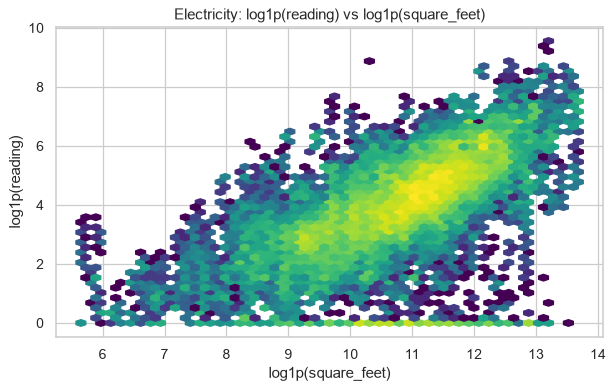

In [20]:
sub = sample[sample.meter == 0].sample(100_000, random_state=0)
plt.figure(figsize=(7, 4.5))
plt.hexbin(np.log1p(sub.square_feet), sub.log_reading, gridsize=50, bins="log", cmap="viridis")
plt.title("Electricity: log1p(reading) vs log1p(square_feet)")
plt.xlabel("log1p(square_feet)")
plt.ylabel("log1p(reading)")
plt.tight_layout()

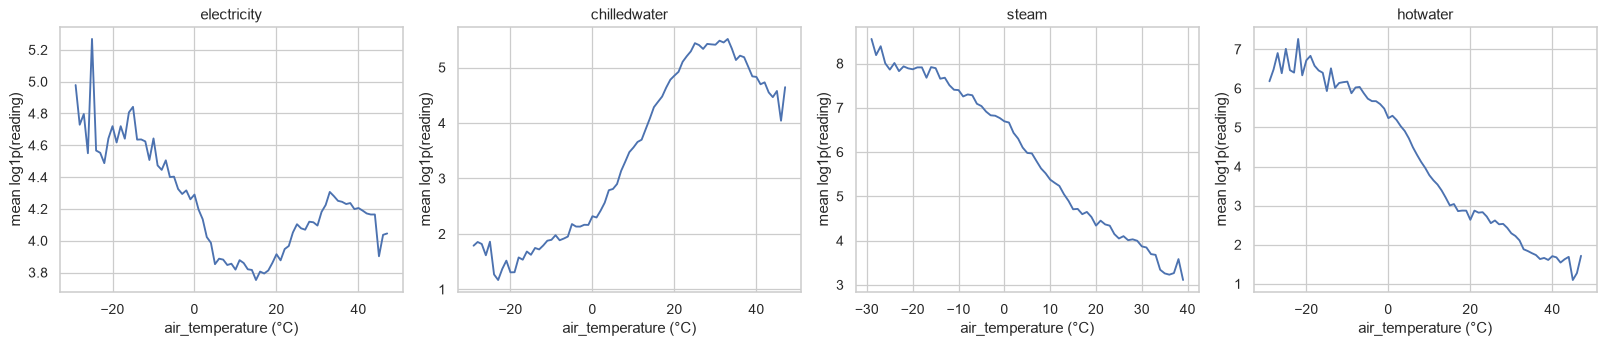

In [21]:
# Weather response differs by meter type: cooling vs heating load
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, (m, name) in zip(axes, METERS.items()):
    s = sample[(sample.meter == m) & sample.air_temperature.notna()]
    s.groupby(s.air_temperature.round()).log_reading.mean().plot(ax=ax)
    ax.set(title=name, xlabel="air_temperature (°C)", ylabel="mean log1p(reading)")
plt.tight_layout()

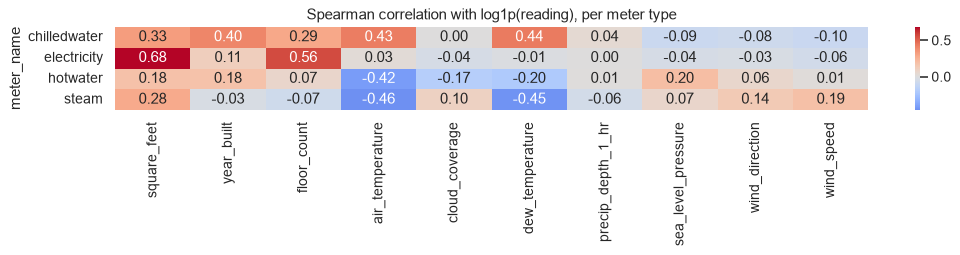

In [22]:
num_cols = [
    "log_reading",
    "square_feet",
    "year_built",
    "floor_count",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
]
corr = (
    sample.assign(square_feet=np.log1p(sample.square_feet))
    .groupby("meter_name")[num_cols]
    .corr(method="spearman")
    .xs("log_reading", level=1)[num_cols[1:]]
)
plt.figure(figsize=(12, 3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation with log1p(reading), per meter type")
plt.tight_layout()

**Takeaways**

- **Floor area is the strongest building feature**, especially for electricity (Spearman ρ = 0.68 with
  `log1p(reading)`; 0.18–0.33 for the other meters). Use `log1p(square_feet)`.
- **Temperature acts in opposite directions:** chilled water rises with it (ρ = 0.43), steam and hot water fall
  (ρ = −0.46 and −0.42), electricity barely reacts. The model has to combine meter type with weather.
- **`air_temperature` and `dew_temperature` carry most of the weather signal.**
- **`precip_depth_1_hr` and `cloud_coverage` are dropped:** precipitation is uncorrelated with the target
  (|ρ| ≤ 0.06), cloud cover only weakly matters for hot water and steam, and they are 36% and 50% missing.

<a id='metric'></a>

# 8. Metric: RMSLE


$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_i \big(\log(1+\hat y_i) - \log(1+y_i)\big)^2}$$

RMSLE is exactly RMSE computed on `log1p(y)`, so the natural setup is to **train on `log1p(meter_reading)` with an MSE loss** and `expm1` the predictions.


In [23]:
def rmsle(y, p):
    return np.sqrt(np.mean((np.log1p(p) - np.log1p(y)) ** 2))


y = np.array([100.0, 100.0, 10_000.0, 10_000.0, 0.0])
cases = {
    "+10% on small value": (y[0], 110.0),
    "-10% on small value": (y[1], 90.0),
    "+10% on large value": (y[2], 11_000.0),
    "absolute +1,000 on large": (y[3], 11_000.0),
    "absolute +1,000 on small": (y[0], 1_100.0),
    "predict 5 when truth is 0": (y[4], 5.0),
}
display(
    pd.DataFrame(
        {
            k: {"y": a, "pred": b, "per-row RMSLE": rmsle(np.array([a]), np.array([b]))}
            for k, (a, b) in cases.items()
        }
    ).T
)

,y,pred,per-row RMSLE
+10% on small value,100.000,110.000,0.094
-10% on small value,100.000,90.000,0.104
+10% on large value,"10,000.000","11,000.000",0.095
"absolute +1,000 on large","10,000.000","11,000.000",0.095
"absolute +1,000 on small",100.000,"1,100.000",2.389
predict 5 when truth is 0,0.000,5.000,1.792


- **Relative error:** a 10% miss costs ≈ 0.095 at any scale, so the few huge series (§5) don't dominate.
- **Harsh near zero:** predicting 5 for a true 0 costs 1.79, 19× a 10% miss. Broken meters reading zero (§9) can
  dominate the score.
- **Also track** RMSLE per meter type and without anomaly rows (done from
  [season_validation.ipynb](../validation/season_validation.ipynb) on).

<a id='broken'></a>

# 9. Anomalies

Some readings don't reflect energy use. Two rules, applied within one building × meter series:

- **Zero electricity:** any electricity reading of exactly 0. A building always draws some power, so a zero is a
  broken meter or a gap in the data feed.
- **Off when needed:** steam or hot water at 0 for at least a week while the mean temperature over that week is below
  10 °C; chilled water the same while above 20 °C. Heating is needed in the cold and cooling in the heat.

Data: `data/processed/train_merged.parquet` from [data_aggregation.ipynb](../preprocessing/data_aggregation.ipynb).

In [24]:
data = read_processed().sort_values(["building_id", "meter", "timestamp"]).reset_index(drop=True)
flags = anomaly_flags(data)
data[["zero_electricity", "off_when_needed"]] = flags[["zero_electricity", "off_when_needed"]]
zero_run_hours = flags.zero_run_hours
data.groupby(data.meter.map(METERS))[["zero_electricity", "off_when_needed"]].mean().mul(100).round(1).rename_axis(
    "% of rows"
)

,zero_electricity,off_when_needed
% of rows,,
chilledwater,0.000,1.000
electricity,4.400,0.000
hotwater,0.000,0.400
steam,0.000,0.800


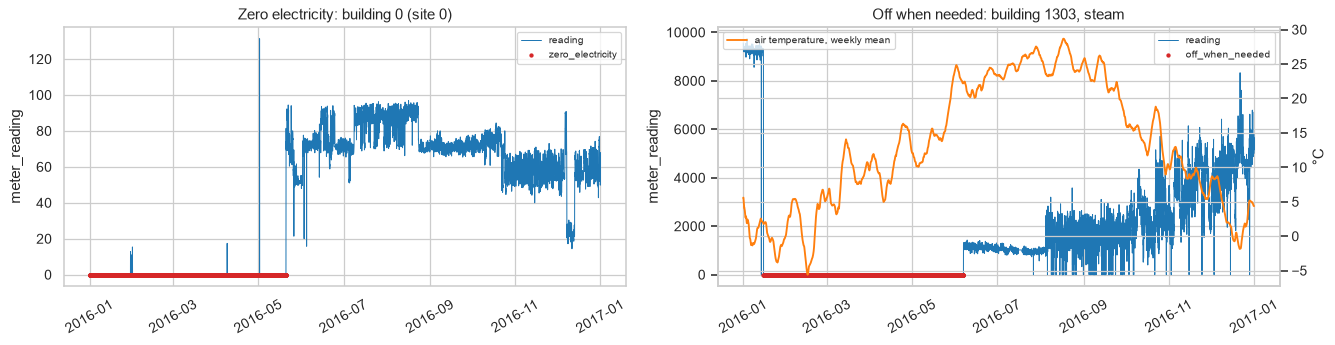

In [25]:
def plot_example(ax, building_id, meter, flag, title):
    s = data[(data.building_id == building_id) & (data.meter == meter)]
    ax.plot(s.timestamp, s.meter_reading, lw=0.8, color="tab:blue", label="reading")
    ax.scatter(s.timestamp[s[flag]], s.meter_reading[s[flag]], s=6, color="tab:red", label=flag, zorder=3)
    ax.set(title=title, ylabel="meter_reading")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper right", fontsize=8)
    return s


fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_example(axes[0], 0, 0, "zero_electricity", "Zero electricity: building 0 (site 0)")
steam = plot_example(axes[1], 1303, 2, "off_when_needed", "Off when needed: building 1303, steam")
temp_ax = axes[1].twinx()
temp_ax.plot(steam.timestamp, steam.air_temperature.rolling(24 * 7, min_periods=1).mean(),
             color="tab:orange", label="air temperature, weekly mean")
temp_ax.set_ylabel("°C")
temp_ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()

## Effect on a model

LightGBM baseline (untuned, `log1p` target) on the same 4 seasonal folds as every model notebook: each validates on
one 3-month block of 2016 and trains on the other nine, 2M / 500K sampled rows per fold
([adversarial.ipynb](../validation/adversarial.ipynb): one block alone tests only one season). Scores are averaged over
the folds.

Anomalies are dropped from **training** only. Validation is scored on all rows, and on clean rows (neither anomaly),
which measures the error on real consumption. Zero electricity is tested with several minimum run lengths. Two
candidate rules are tested on top of both: stuck meters (the same non-zero value for 48+ hours) and spikes (above 10×
the series' median that day). One more variant keeps weather in UTC, as before the fix of §6.1.

In [26]:
import lightgbm as lgb

from ashrae.config import FOLDS
from ashrae.data import clean_weather

N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in the model notebooks
WEATHER = ["air_temperature", "dew_temperature", "sea_level_pressure", "wind_speed", "wind_direction"]
FEATURES = ["meter", "primary_use", "square_feet", "year_built", *WEATHER, "hour", "dayofweek"]

# Two more candidate rules: stuck meters (the same non-zero value for 48+ hours) and spikes (above 10x the series'
# median that day). `data` is sorted by series and time.
series = data.building_id.astype(int) * 4 + data.meter.astype(int)
reading = data.meter_reading
same_value_run = (reading.ne(reading.shift()) | series.ne(series.shift())).cumsum()
data["stuck"] = reading.gt(0) & reading.groupby(same_value_run).transform("size").ge(48)
data["spike"] = reading > 10 * reading.groupby([series, data.timestamp.dt.floor("D")]).transform("median")
del series, reading, same_value_run

data["meter"] = data.meter.astype("category")
data["hour"] = data.local_timestamp.dt.hour
data["dayofweek"] = data.local_timestamp.dt.dayofweek
data["log_reading"] = np.log1p(data.meter_reading)
utc_weather = clean_weather(read_weather("weather_train.csv", WEATHER))  # not shifted to the meters' clock


def in_utc(rows):
    """The same rows with weather left in UTC, as before the §6.1 fix."""
    utc = rows[["site_id", "timestamp"]].merge(utc_weather, on=["site_id", "timestamp"], how="left")
    return rows.assign(**{c: utc[c].to_numpy() for c in WEATHER})


def fit_lgbm(rows):
    model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.1, num_leaves=63, random_state=0, verbose=-1)
    return model.fit(rows[FEATURES], rows.log_reading)


results = []
for fold, months in FOLDS.items():
    is_val = data.timestamp.dt.month.isin(months)
    train_part = data[~is_val].sample(N_TRAIN, random_state=0)
    val_part = data[is_val].sample(N_VAL, random_state=0)
    y_val = val_part.log_reading.to_numpy()
    clean = ~(val_part.zero_electricity | val_part.off_when_needed).to_numpy()
    run_hours = zero_run_hours.loc[train_part.index]
    drops = {
        "keep all": train_part.zero_electricity & False,
        **{f"drop electricity zeros, runs >= {h} h": train_part.zero_electricity & (run_hours >= h)
           for h in [720, 168, 24, 1]},
        "drop off when needed": train_part.off_when_needed,
        "drop all electricity zeros + off when needed": train_part.zero_electricity | train_part.off_when_needed,
        "both rules + stuck meters": train_part.zero_electricity | train_part.off_when_needed | train_part.stuck,
        "both rules + spikes": train_part.zero_electricity | train_part.off_when_needed | train_part.spike,
    }
    variants = {name: (train_part[~drop], val_part) for name, drop in drops.items()}
    variants["keep all, weather in UTC"] = (in_utc(train_part), in_utc(val_part))
    for name, (rows, val_rows) in variants.items():
        pred = fit_lgbm(rows).predict(val_rows[FEATURES])
        results.append({"fold": fold, "variant": name, "train rows dropped": 1 - len(rows) / N_TRAIN,
                        "all rows": rmsle_log(y_val, pred), "clean rows": rmsle_log(y_val[clean], pred[clean])})
    print(f"{fold}: {clean.mean():.1%} of validation rows are clean")

results = pd.DataFrame(results)
for score in ["all rows", "clean rows"]:
    table = results.pivot(index="variant", columns="fold", values=score).loc[list(variants), list(FOLDS)]
    table["average"] = table.mean(axis=1)
    table["train rows dropped"] = results.groupby("variant")["train rows dropped"].mean().map("{:.1%}".format)
    display(table.round(3).rename_axis(f"RMSLE, {score}"))

Jan–Mar: 93.9% of validation rows are clean


Apr–Jun: 96.4% of validation rows are clean


Jul–Sep: 98.7% of validation rows are clean


Oct–Dec: 98.9% of validation rows are clean


fold,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec,average,train rows dropped
"RMSLE, all rows",,,,,,
keep all,1.363,1.187,1.211,1.383,1.286,0.0%
"drop electricity zeros, runs >= 720 h",1.414,1.256,1.202,1.272,1.286,1.6%
"drop electricity zeros, runs >= 168 h",1.452,1.274,1.173,1.224,1.281,2.0%
"drop electricity zeros, runs >= 24 h",1.466,1.282,1.172,1.206,1.281,2.4%
"drop electricity zeros, runs >= 1 h",1.476,1.282,1.169,1.194,1.280,2.6%
drop off when needed,1.365,1.200,1.195,1.361,1.280,0.3%
drop all electricity zeros + off when needed,1.485,1.301,1.171,1.168,1.281,3.0%
both rules + stuck meters,1.482,1.301,1.172,1.169,1.281,4.5%
both rules + spikes,1.489,1.297,1.162,1.165,1.278,3.8%


fold,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec,average,train rows dropped
"RMSLE, clean rows",,,,,,
keep all,1.065,1.039,1.132,1.326,1.140,0.0%
"drop electricity zeros, runs >= 720 h",1.051,1.018,1.108,1.203,1.095,1.6%
"drop electricity zeros, runs >= 168 h",1.041,1.029,1.075,1.154,1.075,2.0%
"drop electricity zeros, runs >= 24 h",1.045,1.022,1.072,1.131,1.067,2.4%
"drop electricity zeros, runs >= 1 h",1.049,1.012,1.066,1.118,1.061,2.6%
drop off when needed,1.051,1.031,1.104,1.301,1.122,0.3%
drop all electricity zeros + off when needed,1.044,1.012,1.050,1.085,1.048,3.0%
both rules + stuck meters,1.042,1.012,1.052,1.087,1.048,4.5%
both rules + spikes,1.049,1.007,1.041,1.083,1.045,3.8%


- **On clean rows, dropping anomalies helps in every fold:** fold average 1.140 → 1.048 with both rules. Zero
  electricity does most of it (1.061 alone). Shorter minimum runs work better (30 days 1.095, 1 week 1.075, 1 day
  1.067, every zero 1.061): even a few hours of zeros teach the model that a building can use no power. Off when
  needed alone: 1.140 → 1.122.
- **On all rows, the average barely moves:** 1.286 → 1.281. Jul–Sep and Oct–Dec improve (1.211 → 1.171,
  1.383 → 1.168); Jan–Mar and Apr–Jun get worse (1.363 → 1.485, 1.187 → 1.301). Those two have the most anomalies in
  validation (6.1% and 3.6% of rows) and still improve on clean rows, so the loss is on the anomaly rows: a model
  trained on a broken meter's zeros predicts low values, which pays off when the outage continues into the validation
  months.
- **So the effect on the Kaggle score depends on the test set's outages.** The models keep dropping anomalies (3.0% of
  training rows): the clean-row score rewards it, and whether 2016's outages continue into 2017–2018 can't be checked
  without a leaderboard score. Every model is scored on both all and clean rows
  ([season_validation.ipynb](../validation/season_validation.ipynb)).
- **Oct–Dec alone overstated the gain:** 1.383 → 1.168 there, the number this notebook reported before it switched to
  folds.
- **Stuck meters and spikes add nothing:** on top of both rules, 1.048 and 1.045 on clean rows (vs 1.048), 1.281 and
  1.278 on all rows, while dropping another 1.5% and 0.8% of training rows. Left out.
- **Validation keeps anomaly rows:** the test set has its own outages, which no model can predict. They cost up to
  0.48 RMSLE per fold ([season_validation.ipynb](../validation/season_validation.ipynb)).

<a id='summary'></a>

# 10. Summary

- **Validation:** 4 seasonal folds, each a 3-month block of 2016 (§9).
- **Target:** train on `log1p(meter_reading)` with MSE loss, which is exactly RMSLE (§8).
- **Units:** convert site 0 electricity from kBTU to kWh (× 0.2931) before training, and back for the submission.
- **Meter types behave differently** in scale, zeros and response to temperature (§5–7). Model them separately or
  give the model a strong meter input.
- **Time zones:** weather is UTC, meters are local except at site 14 (§6.1). Shift weather per site before merging.
- **Anomalies:** drop every zero electricity reading, and heating/cooling meters at zero when they're needed, from
  training (§9): LightGBM 1.140 → 1.048 on clean rows. On all rows the effect depends on the season and averages out
  (1.286 → 1.281).
- **Weather:** keep air and dew temperature, pressure and wind; drop precipitation and cloud coverage (§7). Fill gaps
  per site; some sites lack a column entirely (§3).
- **Buildings:** use `log1p(square_feet)`; `year_built` and `floor_count` are mostly empty (§3).
- **Joins:** always left-join from the meter readings, so no target rows are lost.

Implemented in [data_aggregation.ipynb](../preprocessing/data_aggregation.ipynb); models in [mlp.ipynb](../models/mlp.ipynb).